# Comparison - Poisson vs Quantile

Two models trained on the same annual split, differing only in what they
predict:

| Model | Target | Notebook |
| --- | --- | --- |
| Poisson | conditional **mean** demand | `04-train-annual` |
| Quantile | 80th / 90th **percentile** of demand | `05-train-quantile` |

The Poisson model is accurate on average and under-calls busy hours by 71%.
That is not a defect in the fit - the conditional mean of a spiky distribution
*is* low. It is the wrong quantity to predict when the cost of being short is
higher than the cost of being over.

The two cannot be ranked on MAE: MAE rewards the median, which is what the
quantile models deliberately abandon. This notebook compares them on cost
instead.

| Step | What |
| --- | --- |
| 1 | Load both models and the frozen split |
| 2 | Metrics: accuracy vs operational cost |
| 3 | Where each model fails |
| 4 | The trade-off |
| 5 | Recommendation |

## Step 1 - Load

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

SPLIT = Path("/opt/data/ml/split/annual")
contract = json.loads((SPLIT / "split.json").read_text())

TARGET = contract["target"]
FEATURES = contract["features"]
PEAK_HOURS = contract["peak_hours"]
BUSY = contract["busy_threshold"]

train = pd.read_parquet(SPLIT / "train.parquet")
test = pd.read_parquet(SPLIT / "test.parquet")

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("bike-demand-annual")

print(f"train {len(train):,} | test {len(test):,} | {len(FEATURES)} features")

train 1,280,712 | test 586,920 | 17 features


In [2]:
# Both notebooks used the same sweep-winning hyperparameters, so the only
# difference between these models is the loss.
BASE = {
    "learning_rate": 0.05, "max_leaf_nodes": 127, "max_iter": 600,
    "max_features": 0.7, "early_stopping": False, "random_state": 0,
}


def build(**overrides):
    return Pipeline([
        ("prep", ColumnTransformer(
            [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
              ["season"])],
            remainder="passthrough",
        )),
        ("model", HistGradientBoostingRegressor(**{**BASE, **overrides})),
    ])


SPECS = {
    "poisson": {"loss": "poisson"},
    "q80": {"loss": "quantile", "quantile": 0.8},
    "q90": {"loss": "quantile", "quantile": 0.9},
}

preds = {}
for name, spec in SPECS.items():
    m = build(**spec)
    m.fit(train[FEATURES], train[TARGET])
    preds[name] = np.clip(m.predict(test[FEATURES]), 0, None)
    print(f"{name:8} fitted")

# the reference every model has had to beat since model selection
KEYS = ["station_id", "hour", "weekday"]
lookup = train.groupby(KEYS)[TARGET].mean().rename("p")
preds["baseline"] = (test[KEYS].join(lookup, on=KEYS)["p"]
                     .fillna(train[TARGET].mean()).to_numpy())

poisson  fitted
q80      fitted
q90      fitted


## Step 2 - Accuracy vs cost

Two families of metric, and they disagree by design:

- **Accuracy** (`MAE`, `MAE_peak`) - how close on average. Dominated by the 59%
  of rows that are zero.
- **Cost** (`shortfall_busy`, `unmet_demand`, `over_supply`) - what the errors
  mean operationally. `unmet_demand` is the total departures a station could
  not serve if it were stocked to the prediction.

In [3]:
def evaluate(y_true, y_pred, hours):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    y_true = np.asarray(y_true, dtype=float)
    busy = y_true >= BUSY
    peak = np.isin(hours, PEAK_HOURS)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAE_peak": mean_absolute_error(y_true[peak], y_pred[peak]),
        "shortfall_busy": 1 - y_pred[busy].sum() / y_true[busy].sum(),
        "unmet_demand": float(np.maximum(y_true - y_pred, 0).sum()),
        "over_supply": float(np.maximum(y_pred - y_true, 0).sum()),
    }


ORDER = ["baseline", "poisson", "q80", "q90"]
results = pd.DataFrame(
    {n: evaluate(test[TARGET], preds[n], test["hour"]) for n in ORDER}
).T

total = test[TARGET].sum()
results["unmet_pct"] = results["unmet_demand"] / total
results["over_pct"] = results["over_supply"] / total

print(f"test 2022 - {total:,.0f} annual departures\n")
print(results.round(4).to_string())

test 2022 - 490,673 annual departures

             MAE  MAE_peak  shortfall_busy  unmet_demand  over_supply  unmet_pct  over_pct
baseline  0.8645    1.3632          0.6711   216775.6081  290628.3608     0.4418    0.5923
poisson   0.7625    1.1291          0.7092   223704.9797  223837.9166     0.4559    0.4562
q80       1.0513    1.5588          0.5556   111944.8194  505065.3034     0.2281    1.0293
q90       1.4694    2.1022          0.4413    63351.6495  799049.0921     0.1291    1.6285


## Step 3 - Where each model fails

In [4]:
bands = pd.cut(test[TARGET], [-0.1, 0, 2, 5, 10, np.inf],
               labels=["0", "1-2", "3-5", "6-10", "11+"])

by_band = pd.DataFrame({
    "rows": test.groupby(bands, observed=True).size(),
    "actual": test.groupby(bands, observed=True)[TARGET].mean(),
})
for n in ["poisson", "q80", "q90"]:
    by_band[n] = pd.Series(preds[n], index=test.index).groupby(
        bands, observed=True).mean()

print("mean prediction by demand level\n")
print(by_band.round(3).to_string())

# Share of trips lost, by hour: an average over the day hides the commute.
hourly = test[["hour", TARGET]].copy()
for n in ["poisson", "q80", "q90"]:
    hourly[n] = np.maximum(test[TARGET].to_numpy() - preds[n], 0)
unmet_by_hour = hourly.groupby("hour").sum()
unmet_by_hour = unmet_by_hour[["poisson", "q80", "q90"]].div(
    hourly.groupby("hour")[TARGET].sum(), axis=0)

print("\n\nunmet demand at the evening peak (16-19)\n")
print(unmet_by_hour.loc[16:19].round(3).to_string())

mean prediction by demand level

              rows  actual  poisson    q80    q90
trip_count                                       
0           346514   0.000    0.483  0.932  1.379
1-2         179457   1.322    1.115  1.993  2.707
3-5          51568   3.589    1.881  3.139  4.079
6-10          8822   6.963    2.739  4.340  5.498
11+            559  12.265    3.566  5.451  6.853


unmet demand at the evening peak (16-19)

      poisson    q80    q90
hour                       
16      0.383  0.159  0.088
17      0.378  0.160  0.087
18      0.350  0.146  0.079
19      0.344  0.138  0.072


## Step 4 - The trade-off

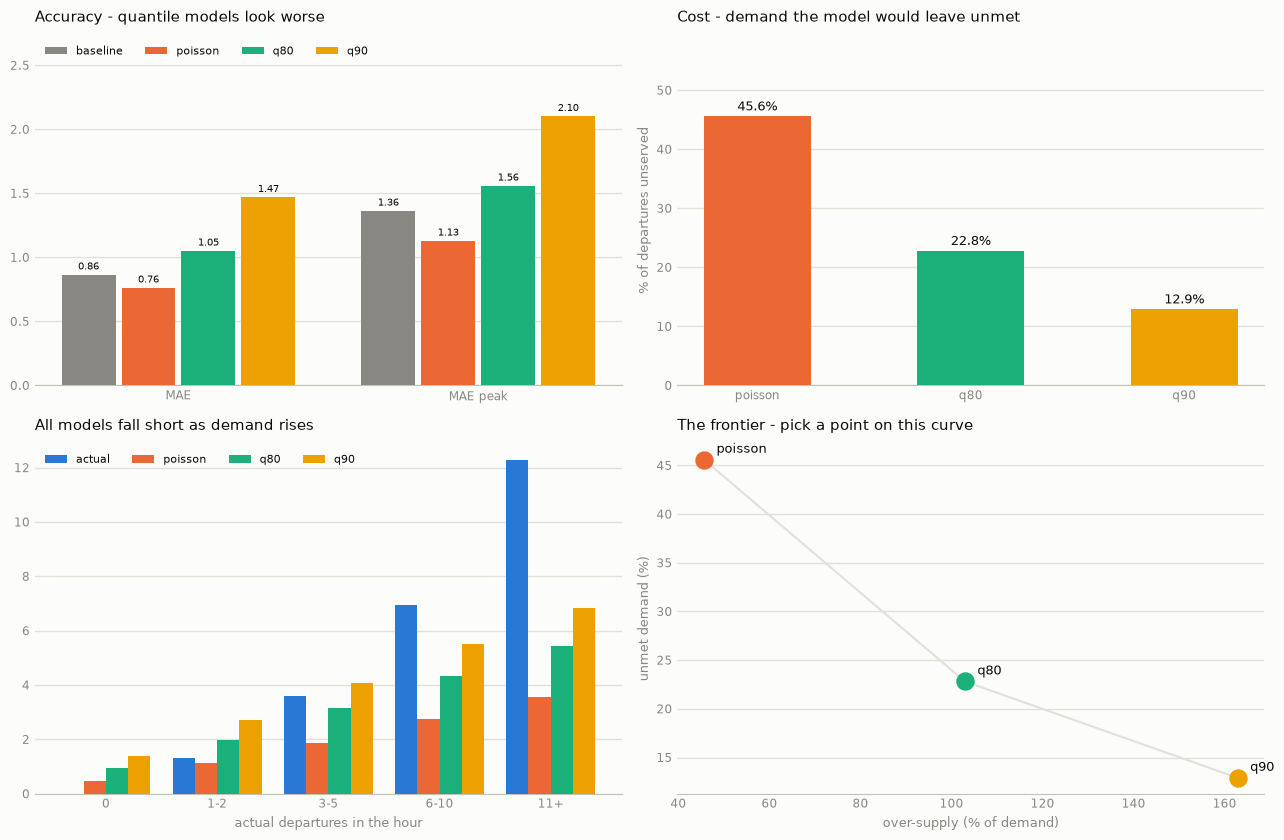

In [5]:
# validated categorical slots 1-4
C = {"actual": "#2a78d6", "baseline": "#898781", "poisson": "#eb6834",
     "q80": "#1baf7a", "q90": "#eda100"}
INK, MUTED, GRID_C, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"
SHOW = ["poisson", "q80", "q90"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), facecolor=SURFACE)
(ax1, ax2), (ax3, ax4) = axes

# --- 1. accuracy: the quantile models look worse here ---
x = np.arange(2)
for i, n in enumerate(ORDER):
    b = ax1.bar(x + (i - 1.5) * 0.2, [results.loc[n, "MAE"],
                                      results.loc[n, "MAE_peak"]],
                0.18, label=n, color=C[n], zorder=3)
    ax1.bar_label(b, fmt="%.2f", padding=2, fontsize=7.5, color=INK)
ax1.set_xticks(x, ["MAE", "MAE peak"], fontsize=9, color=INK)
ax1.set_title("Accuracy - quantile models look worse", fontsize=11,
              color=INK, loc="left", pad=10)
ax1.set_ylim(0, results["MAE_peak"].max() * 1.3)
ax1.legend(frameon=False, ncols=4, fontsize=8, labelcolor=INK, loc="upper left")

# --- 2. cost: and better on the thing that matters ---
for i, n in enumerate(SHOW):
    b = ax2.bar(i, results.loc[n, "unmet_pct"] * 100, 0.5, color=C[n], zorder=3)
    ax2.bar_label(b, fmt="%.1f%%", padding=2, fontsize=9, color=INK)
ax2.set_xticks(range(len(SHOW)), SHOW, fontsize=9, color=INK)
ax2.set_ylabel("% of departures unserved", fontsize=9, color=MUTED)
ax2.set_title("Cost - demand the model would leave unmet", fontsize=11,
              color=INK, loc="left", pad=10)
ax2.set_ylim(0, results.loc[SHOW, "unmet_pct"].max() * 130)

# --- 3. predicted vs actual by demand band ---
bx = np.arange(len(by_band))
ax3.bar(bx - 0.3, by_band["actual"], 0.2, label="actual", color=C["actual"], zorder=3)
for i, n in enumerate(SHOW):
    ax3.bar(bx + (i - 0.5) * 0.2, by_band[n], 0.2, label=n, color=C[n], zorder=3)
ax3.set_xticks(bx, by_band.index, fontsize=9, color=INK)
ax3.set_xlabel("actual departures in the hour", fontsize=9, color=MUTED)
ax3.set_title("All models fall short as demand rises", fontsize=11,
              color=INK, loc="left", pad=10)
ax3.legend(frameon=False, ncols=4, fontsize=8, labelcolor=INK, loc="upper left")

# --- 4. the frontier ---
for n in SHOW:
    ax4.scatter(results.loc[n, "over_pct"] * 100, results.loc[n, "unmet_pct"] * 100,
                s=150, color=C[n], zorder=3)
    ax4.annotate(n, (results.loc[n, "over_pct"] * 100,
                     results.loc[n, "unmet_pct"] * 100),
                 textcoords="offset points", xytext=(9, 5),
                 fontsize=9.5, color=INK)
ax4.plot(results.loc[SHOW, "over_pct"] * 100,
         results.loc[SHOW, "unmet_pct"] * 100,
         color=GRID_C, lw=1.5, zorder=2)
ax4.set_xlabel("over-supply (% of demand)", fontsize=9, color=MUTED)
ax4.set_ylabel("unmet demand (%)", fontsize=9, color=MUTED)
ax4.set_title("The frontier - pick a point on this curve", fontsize=11,
              color=INK, loc="left", pad=10)

for ax in (ax1, ax2, ax3, ax4):
    ax.set_facecolor(SURFACE)
    ax.yaxis.grid(True, color=GRID_C, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(axis="both", length=0, colors=MUTED, labelsize=8.5)

fig.tight_layout()
fig.savefig("/tmp/comparison.png", dpi=140, facecolor=SURFACE, bbox_inches="tight")
plt.show()

## Step 5 - Recommendation

In [6]:
verdict = pd.DataFrame({
    "MAE": results["MAE"],
    "unmet %": results["unmet_pct"] * 100,
    "over %": results["over_pct"] * 100,
    "busy shortfall %": results["shortfall_busy"] * 100,
}).round(2)

print(verdict.to_string())
print(f"\nq80 vs poisson: unmet demand "
      f"{1 - results.loc['q80', 'unmet_pct'] / results.loc['poisson', 'unmet_pct']:.1%} lower, "
      f"over-supply {results.loc['q80', 'over_pct'] / results.loc['poisson', 'over_pct']:.1f}x higher")

           MAE  unmet %  over %  busy shortfall %
baseline  0.86    44.18   59.23             67.11
poisson   0.76    45.59   45.62             70.92
q80       1.05    22.81  102.93             55.56
q90       1.47    12.91  162.85             44.13

q80 vs poisson: unmet demand 50.0% lower, over-supply 2.3x higher


### Verdict

**Ship q80.**

The Poisson model has the better MAE and is the wrong model for the job. It
predicts the average hour, so it is short on every busy one - and a station that
is short is a rider who walks. Its low MAE is earned on the 59% of rows where
demand is zero and nothing is at stake.

q80 gives back accuracy on the quiet hours to buy coverage on the busy ones.
q90 buys more, at an over-supply cost that means materially more van trips for
a smaller marginal gain.

**What none of them do:** predict a spike. Even q90 under-calls every hour with
11+ actual departures. Quantile regression widens the safety margin, it does not
give the model sight of what causes a surge. That needs an external signal -
weather being the obvious one, and unavailable here.

**Serving note:** the prediction is a stocking target, not a demand forecast.
"Stock to this level and you will serve ~80% of hours" is what q80 means; it
should not be presented as expected demand.